# Decision Tree Evaluation — Medical Suitability Classifier

Trains and evaluates the `DecisionTreeClassifier` from `decision_tree.py`
(medical suitability for Hypertension / Diabetes) using an **80/20
train/test split** on `food_table_clean.csv`. The `.joblib` model file is
trained and saved fresh by this notebook — nothing is loaded from a
pre-built artifact.

This notebook imports `build_training_data`, `FEATURE_COLS`,
`SODIUM_THRESHOLD`, and `SUGAR_THRESHOLD` **directly from `decision_tree.py`**
(rather than reimplementing that logic here), so the labels and features
used for evaluation are guaranteed to match production exactly. Only the
train/test split and evaluation are done in the notebook — `decision_tree.py`
itself is not modified.

**What this model actually predicts:** the labels aren't clinical ground
truth or user behavior — they're generated from two fixed rules inside
`build_training_data`:

- `Hypertension`: unsuitable (`0`) if `sodium_mg > 400` (WHO sodium proxy), else suitable (`1`)
- `Diabetes`: unsuitable (`0`) if `sugar_g > 15` (ADA sugar proxy), else suitable (`1`)

So this evaluation asks: **"How well does the shallow (max_depth=4) tree
recover these two thresholds on foods it never saw during training?"**

**Sections:**
1. Setup & import `decision_tree.py`
2. Load data and build labels (via `decision_tree.build_training_data`)
3. 80/20 stratified train/test split
4. Train the model on the 80% split and save `decision_tree.joblib`
5. Accuracy, precision, recall, F1, ROC-AUC (on the held-out 20%)
6. Confusion matrix heatmaps (overall + per-condition)
7. Cross-validation
8. Feature importance
9. Tree visualization
10. Threshold sanity check (learned split vs. 400mg / 15g)
11. Error inspection


## 1. Setup & import `decision_tree.py`

`decision_tree.py` imports `django.conf.settings` at module level (to build
`MODEL_PATH`), so Django's settings need to be configured before import —
this is the standard way to use Django-dependent code outside a full
project/management command. `BASE_DIR` is only needed so the module can
import cleanly; this notebook does **not** write to `MODEL_PATH` — it saves
its own fresh `.joblib` locally (see Section 4).


In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report,
)
import joblib

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)


In [2]:
import django
from django.conf import settings

if not settings.configured:
    settings.configure(BASE_DIR=os.getcwd())
    django.setup()

import decision_tree as dt  # the actual production module being evaluated

print("Imported decision_tree.py")
print("SODIUM_THRESHOLD:", dt.SODIUM_THRESHOLD)
print("SUGAR_THRESHOLD:", dt.SUGAR_THRESHOLD)
print("FEATURE_COLS:", dt.FEATURE_COLS)


Imported decision_tree.py
SODIUM_THRESHOLD: 400
SUGAR_THRESHOLD: 15
FEATURE_COLS: ['sodium_mg', 'sugar_g', 'carbs_g', 'fat_g', 'calories', 'condition_Diabetes', 'condition_Hypertension']


## 2. Load data and build labels

`dt.build_training_data(foods_df)` is called directly from the production
module — same thresholds, same one-hot condition encoding as what actually
ships. Each of the 225 foods produces 2 rows (one per condition), giving 450
labelled rows.


In [3]:
FOOD_CSV = "food_table_clean.csv"

foods_df = pd.read_csv(FOOD_CSV)
print(f"Loaded {len(foods_df)} foods")

train_df = dt.build_training_data(foods_df)
print(f"{len(foods_df)} foods x 2 conditions = {len(train_df)} labelled rows")

train_df.groupby(train_df["condition_Hypertension"])["suitable"].value_counts()


Loaded 225 foods
225 foods x 2 conditions = 450 labelled rows


condition_Hypertension  suitable
False                   1           218
                        0             7
True                    1           205
                        0            20
Name: count, dtype: int64

### Class balance check

Worth checking before trusting accuracy alone — if a condition's labels are
heavily skewed toward "suitable", a model predicting the majority class
would still score high on accuracy. Recall on the *unsuitable* class matters
more for this use case: a false negative (model says "suitable" when the
rule says it isn't) is the costlier mistake for a medical-suitability filter.


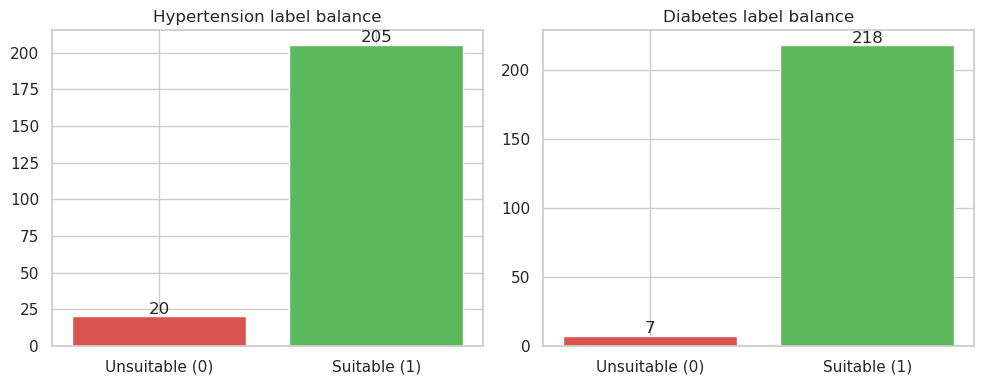

condition     suitable
Diabetes      1           0.969
              0           0.031
Hypertension  1           0.911
              0           0.089
Name: proportion, dtype: float64

In [4]:
condition_label = np.where(train_df["condition_Hypertension"], "Hypertension", "Diabetes")
balance = pd.DataFrame({"condition": condition_label, "suitable": train_df["suitable"]})

fig, ax = plt.subplots(1, 2, figsize=(10, 4))
for i, cond in enumerate(["Hypertension", "Diabetes"]):
    subset = balance[balance["condition"] == cond]
    counts = subset["suitable"].value_counts().reindex([0, 1]).fillna(0)
    ax[i].bar(["Unsuitable (0)", "Suitable (1)"], counts.values, color=["#d9534f", "#5cb85c"])
    ax[i].set_title(f"{cond} label balance")
    for j, v in enumerate(counts.values):
        ax[i].text(j, v + 2, int(v), ha="center")
plt.tight_layout()
plt.show()

balance.groupby("condition")["suitable"].value_counts(normalize=True).round(3)


## 3. Build X / y, then the 80/20 stratified split

`stratify=y` keeps the suitable/unsuitable ratio consistent across train and
test. `X_test`/`y_test` are held out completely from training and only used
for evaluation from Section 5 onward.


In [5]:
X = train_df[dt.FEATURE_COLS]
y = train_df["suitable"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y,
)

print(f"Train: {len(X_train)} rows ({len(X_train)/len(X):.0%})")
print(f"Test:  {len(X_test)} rows ({len(X_test)/len(X):.0%})")


Train: 360 rows (80%)
Test:  90 rows (20%)


## 4. Train on the 80% split and save `decision_tree.joblib`

`max_depth=4` matches the production model's architecture (see
`decision_tree.py`'s module docstring — capped for explainability). Only
`X_train`/`y_train` are used to fit. The `.joblib` is written fresh to this
notebook's working directory — it is **not** the production artifact (which
`train_and_save`/`train_decision_tree` fits on 100% of the data) and
shouldn't be copied over it; it exists so this evaluation is self-contained
and reproducible.


In [6]:
clf = DecisionTreeClassifier(max_depth=4, random_state=RANDOM_STATE)
clf.fit(X_train, y_train)

joblib.dump(clf, "decision_tree.joblib")
print("Trained on", len(X_train), "rows, saved to 'decision_tree.joblib'")

print(f"\nTrain accuracy (80% split): {clf.score(X_train, y_train):.1%}")
print(f"Test accuracy  (20% held-out): {clf.score(X_test, y_test):.1%}")


Trained on 360 rows, saved to 'decision_tree.joblib'

Train accuracy (80% split): 100.0%
Test accuracy  (20% held-out): 100.0%


In [7]:
y_pred = clf.predict(X_test)
y_proba = clf.predict_proba(X_test)[:, 1]


## 5. Core metrics — accuracy, precision, recall, F1, ROC-AUC

In [8]:
metrics = {
    "Accuracy": accuracy_score(y_test, y_pred),
    "Precision (suitable=1)": precision_score(y_test, y_pred, pos_label=1),
    "Recall (suitable=1)": recall_score(y_test, y_pred, pos_label=1),
    "F1 (suitable=1)": f1_score(y_test, y_pred, pos_label=1),
    "Precision (unsuitable=0)": precision_score(y_test, y_pred, pos_label=0),
    "Recall (unsuitable=0)": recall_score(y_test, y_pred, pos_label=0),
    "F1 (unsuitable=0)": f1_score(y_test, y_pred, pos_label=0),
    "ROC-AUC": roc_auc_score(y_test, y_proba),
}

metrics_df = pd.DataFrame(metrics.items(), columns=["Metric", "Value"])
metrics_df["Value"] = metrics_df["Value"].round(3)
metrics_df


,Metric,Value
0,Accuracy,1.0
1,Precision (suitable=1),1.0
2,Recall (suitable=1),1.0
3,F1 (suitable=1),1.0
4,Precision (unsuitable=0),1.0
5,Recall (unsuitable=0),1.0
6,F1 (unsuitable=0),1.0
7,ROC-AUC,1.0


In [9]:
print("Full classification report (held-out test set):\n")
print(classification_report(y_test, y_pred, target_names=["Unsuitable (0)", "Suitable (1)"]))


Full classification report (held-out test set):

                precision    recall  f1-score   support

Unsuitable (0)       1.00      1.00      1.00         5
  Suitable (1)       1.00      1.00      1.00        85

      accuracy                           1.00        90
     macro avg       1.00      1.00      1.00        90
  weighted avg       1.00      1.00      1.00        90



**Reading this for the actual use case:** recall on class `0` (unsuitable)
matters most — a false negative means the app tells someone with
Hypertension or Diabetes that a food is fine when the rule says it isn't. A
false positive (flagging a fine food as unsuitable) just costs some variety
— a much cheaper mistake. Watch for recall on class 0 lagging class 1 even
if overall accuracy looks fine.


## 6. Confusion matrix heatmaps — overall and per condition

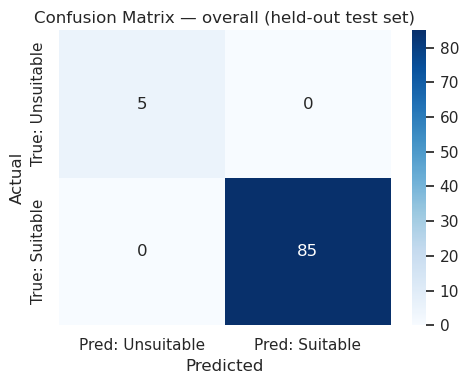

In [10]:
cm = confusion_matrix(y_test, y_pred, labels=[0, 1])

plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Pred: Unsuitable", "Pred: Suitable"],
            yticklabels=["True: Unsuitable", "True: Suitable"])
plt.title("Confusion Matrix — overall (held-out test set)")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.tight_layout()
plt.show()


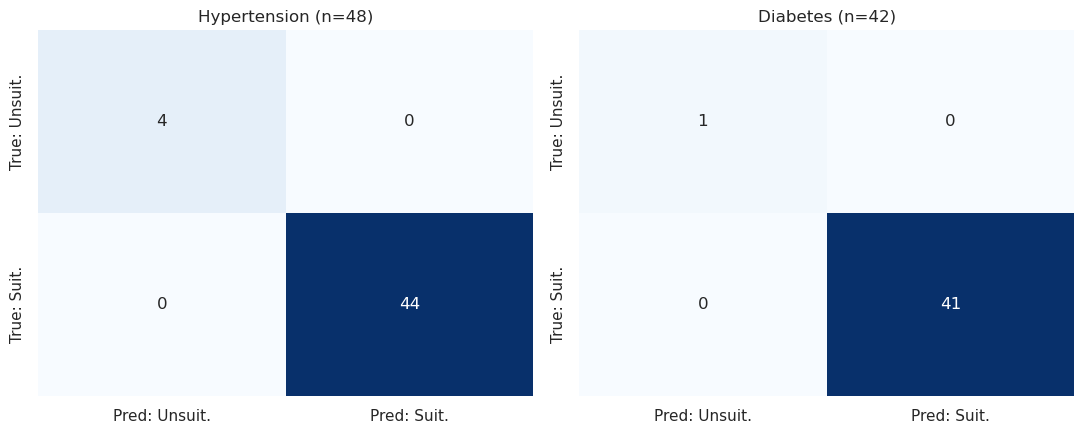

In [11]:
# Per-condition breakdown: is error concentrated in one condition's rule?
test_conditions = np.where(X_test["condition_Hypertension"], "Hypertension", "Diabetes")

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
for ax, cond in zip(axes, ["Hypertension", "Diabetes"]):
    mask = test_conditions == cond
    if mask.sum() == 0:
        ax.set_title(f"{cond} (no test rows in this split)")
        ax.axis("off")
        continue
    cm_c = confusion_matrix(y_test[mask], y_pred[mask], labels=[0, 1])
    sns.heatmap(cm_c, annot=True, fmt="d", cmap="Blues", ax=ax, cbar=False,
                xticklabels=["Pred: Unsuit.", "Pred: Suit."],
                yticklabels=["True: Unsuit.", "True: Suit."])
    ax.set_title(f"{cond} (n={mask.sum()})")
plt.tight_layout()
plt.show()


## 7. Cross-validation

225 foods (450 labelled rows) is a small dataset — a single 80/20 split can
be noisy depending on which foods land in the test fold. Stratified 5-fold
CV (re-splitting the full X/y independently of the split above) gives a more
stable read on expected performance.


In [12]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
scoring = ["accuracy", "precision", "recall", "f1", "roc_auc"]

cv_results = cross_validate(
    DecisionTreeClassifier(max_depth=4, random_state=RANDOM_STATE),
    X, y, cv=cv, scoring=scoring
)

cv_summary = pd.DataFrame({
    metric: [cv_results[f"test_{metric}"].mean(), cv_results[f"test_{metric}"].std()]
    for metric in scoring
}, index=["mean", "std"]).T.round(3)
cv_summary


,mean,std
accuracy,1.0,0.0
precision,1.0,0.0
recall,1.0,0.0
f1,1.0,0.0
roc_auc,1.0,0.0


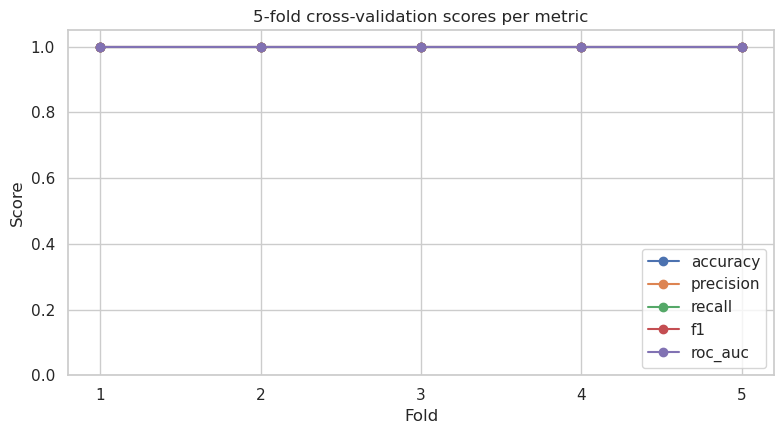

In [13]:
fig, ax = plt.subplots(figsize=(8, 4.5))
for metric in scoring:
    ax.plot(range(1, 6), cv_results[f"test_{metric}"], marker="o", label=metric)
ax.set_xticks(range(1, 6))
ax.set_xlabel("Fold")
ax.set_ylabel("Score")
ax.set_ylim(0, 1.05)
ax.set_title("5-fold cross-validation scores per metric")
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()


## 8. Feature importance

The labels are generated purely from `sodium_mg` (Hypertension) and
`sugar_g` (Diabetes) plus the one-hot condition flags, so a well-fit tree
*should* show those features dominating. Meaningful importance on
`carbs_g`/`fat_g`/`calories` instead would suggest the tree is fitting noise
rather than the actual rule.


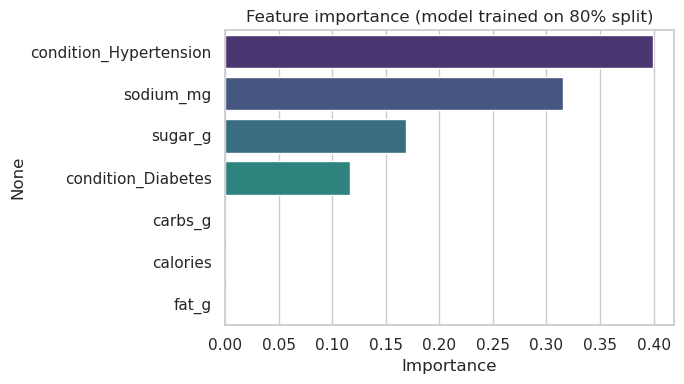

condition_Hypertension    0.399
sodium_mg                 0.316
sugar_g                   0.169
condition_Diabetes        0.116
carbs_g                   0.000
calories                  0.000
fat_g                     0.000
dtype: float64

In [14]:
importances = pd.Series(clf.feature_importances_, index=dt.FEATURE_COLS).sort_values(ascending=False)

plt.figure(figsize=(7, 4))
sns.barplot(x=importances.values, y=importances.index, hue=importances.index,
            palette="viridis", legend=False)
plt.title("Feature importance (model trained on 80% split)")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

importances.round(3)


## 9. Tree visualization

Depth is capped at 4 for explainability (per `decision_tree.py`'s module
docstring), so this should render as a small, readable tree.


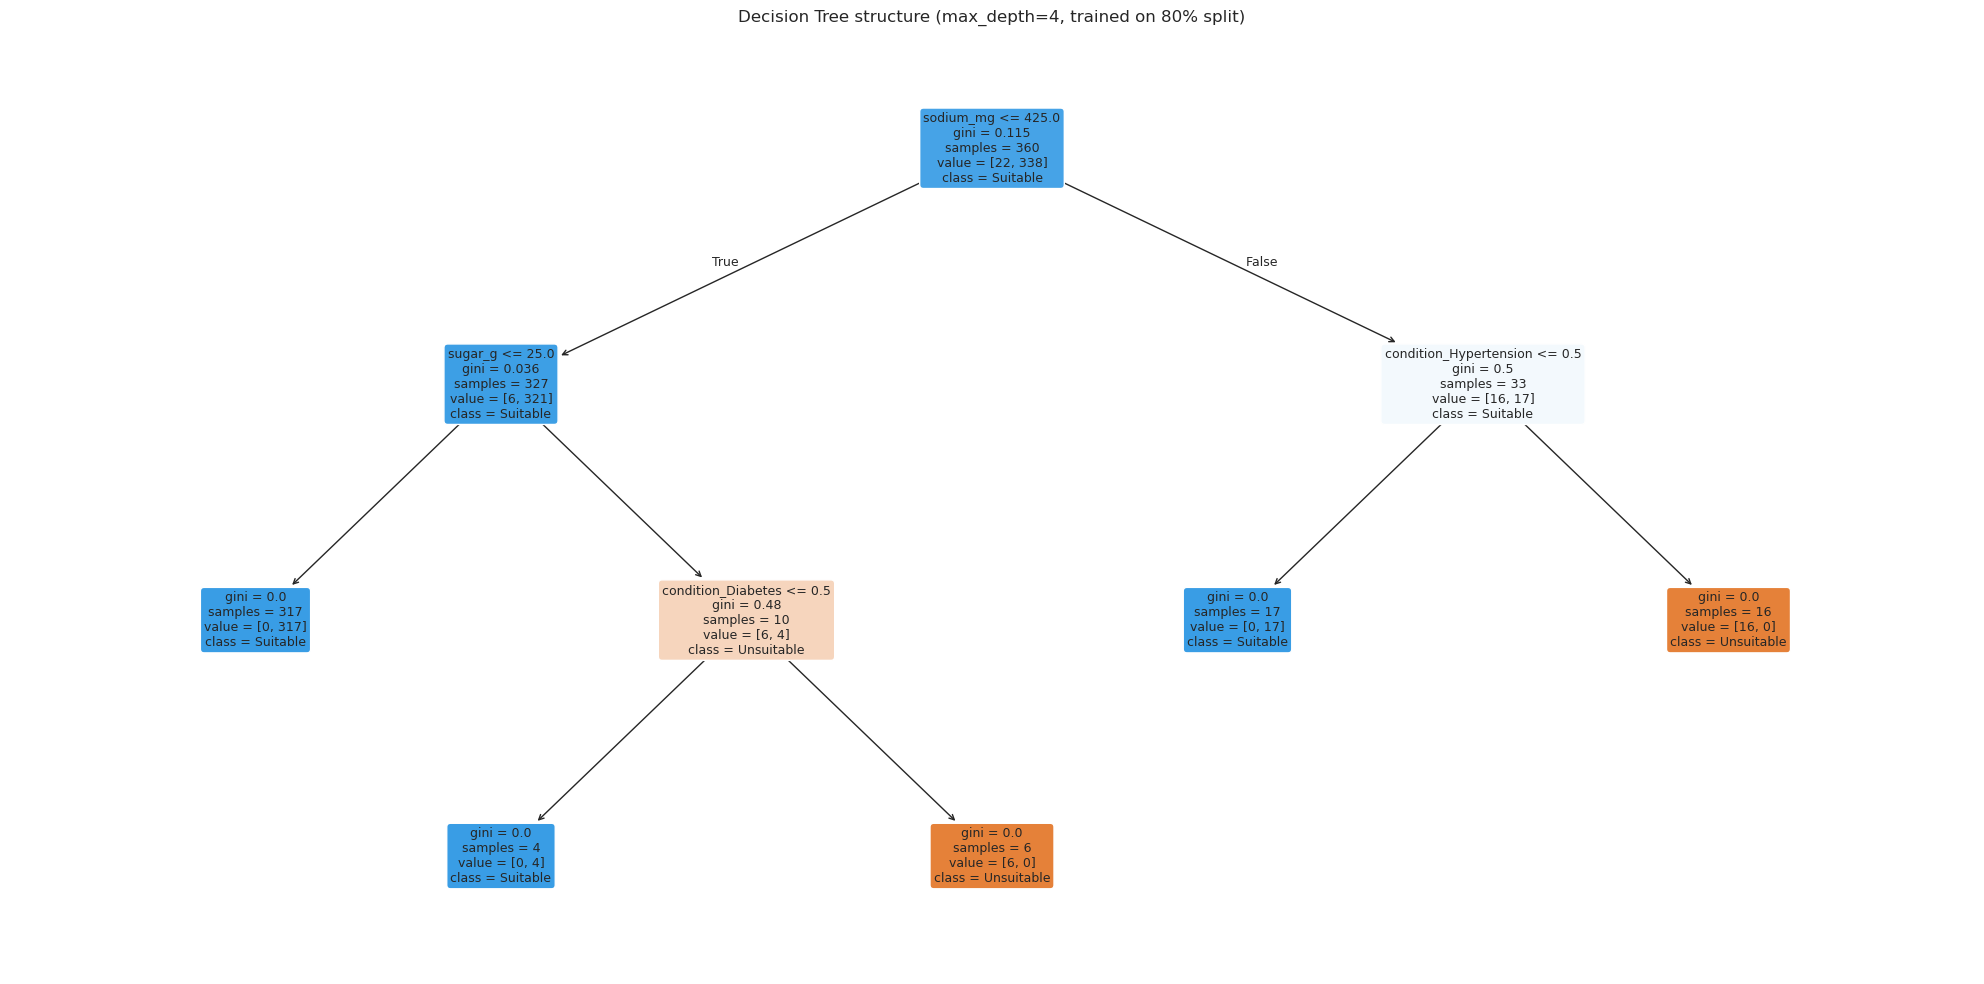

In [15]:
plt.figure(figsize=(20, 10))
plot_tree(
    clf, feature_names=dt.FEATURE_COLS, class_names=["Unsuitable", "Suitable"],
    filled=True, rounded=True, fontsize=9, impurity=True,
)
plt.title("Decision Tree structure (max_depth=4, trained on 80% split)")
plt.tight_layout()
plt.show()


## 10. Threshold sanity check

Compares the tree's learned split points against the two rule thresholds it
approximates (`dt.SODIUM_THRESHOLD`, `dt.SUGAR_THRESHOLD`). The closer these
are, the more faithfully the tree recovered the documented rule rather than
an arbitrary split elsewhere in the data.


In [16]:
tree_ = clf.tree_
learned_splits = []
for i in range(tree_.node_count):
    if tree_.children_left[i] != tree_.children_right[i]:  # not a leaf
        feat = dt.FEATURE_COLS[tree_.feature[i]]
        thresh = tree_.threshold[i]
        learned_splits.append({"feature": feat, "learned_threshold": round(thresh, 2)})

splits_df = pd.DataFrame(learned_splits)
print("All split points learned by the tree:")
display(splits_df)

sodium_splits = splits_df[splits_df["feature"] == "sodium_mg"]
sugar_splits = splits_df[splits_df["feature"] == "sugar_g"]

print(f"\nRule threshold — sodium_mg: {dt.SODIUM_THRESHOLD}")
if not sodium_splits.empty:
    closest = sodium_splits.iloc[(sodium_splits['learned_threshold'] - dt.SODIUM_THRESHOLD).abs().argsort()[:1]]
    print(f"Closest learned sodium_mg split: {closest['learned_threshold'].values[0]}")
else:
    print("No sodium_mg split found in this tree.")

print(f"\nRule threshold — sugar_g: {dt.SUGAR_THRESHOLD}")
if not sugar_splits.empty:
    closest = sugar_splits.iloc[(sugar_splits['learned_threshold'] - dt.SUGAR_THRESHOLD).abs().argsort()[:1]]
    print(f"Closest learned sugar_g split: {closest['learned_threshold'].values[0]}")
else:
    print("No sugar_g split found in this tree.")


All split points learned by the tree:


,feature,learned_threshold
0,sodium_mg,425.0
1,sugar_g,25.0
2,condition_Diabetes,0.5
3,condition_Hypertension,0.5



Rule threshold — sodium_mg: 400
Closest learned sodium_mg split: 425.0

Rule threshold — sugar_g: 15
Closest learned sugar_g split: 25.0


## 11. Error inspection — which specific foods get misclassified

Aggregate metrics can hide *which* foods are affected. Lists every
misclassified row in the held-out test set with its real sodium/sugar values.


In [17]:
foods_lookup = foods_df.set_index(foods_df.index)  # positional alignment with build_training_data's row order

test_idx = X_test.index
errors_mask = y_test.values != y_pred

error_rows = train_df.loc[test_idx[errors_mask]].copy()
error_rows["predicted"] = y_pred[errors_mask]
error_rows["condition"] = np.where(error_rows["condition_Hypertension"], "Hypertension", "Diabetes")

cols = ["condition", "sodium_mg", "sugar_g", "carbs_g", "fat_g", "calories", "suitable", "predicted"]

if error_rows.empty:
    print("No misclassifications on the held-out test set.")
else:
    print(f"{len(error_rows)} misclassified row(s) out of {len(y_test)} test rows:")
    display(error_rows[cols].rename(columns={"suitable": "true_label"}))


No misclassifications on the held-out test set.


## Summary

- This notebook trained on **80%** of the labelled data and evaluated
  exclusively on the held-out **20%** — every metric above is a genuine
  generalization estimate.
- `decision_tree.joblib` in this notebook's working directory was created
  fresh by Section 4. It's a local evaluation artifact, not the production
  model (which is fit on 100% of the data via `train_and_save` /
  `python manage.py train_decision_tree`) — don't copy it over the
  production `.joblib`.
- Section 10 is the most direct check of whether the tree recovered the
  intended rule (thresholds close to 400mg sodium / 15g sugar) rather than
  drifting to an arbitrary split elsewhere in the sparse data.
